In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)


# Exercise 5: Evaluating a Medical AI Model with Metrics

**Research question:**  
Can a simple AI model help identify **malignant breast tumors** from measurements of cell nuclei?

In this exercise, we use a **public medical dataset** and focus on **evaluation metrics**.  We will use **`scikit-learn`**, a very common machine-learning library.

## Why this matters

In medicine, **accuracy alone is not enough**.  
For example, if a model misses a malignant case, that can be more serious than raising a false alarm.

That is why we also look at:

- **Sensitivity**: How many malignant cases did the model catch?
- **Specificity**: How many benign cases did the model correctly leave as benign?
- **Precision**: When the model says “malignant”, how often is it right?

## Learning goals

- read a **confusion matrix**
- understand **accuracy, sensitivity, specificity, and precision**
- see how the **decision threshold** changes the metrics



## 1) Load dataset

We use the **Breast Cancer Wisconsin** dataset.

To make the metrics easier to read, we define:

- **1 = malignant** (positive class)
- **0 = benign** (negative class)

This is a common idea in medicine: the **positive class** is often the condition we most want to detect.


In [2]:

data = load_breast_cancer(as_frame=True)

X = data.data
y = (data.target == 0).astype(int)   # 1 = malignant, 0 = benign

preview_cols = ["mean radius", "mean texture", "mean area", "mean smoothness"]
preview_df = X[preview_cols].copy()
preview_df["malignant"] = y

print(f"Number of patients: {len(X)}")
print(f"Malignant cases: {y.mean():.1%}")
print()
preview_df.head()


Number of patients: 569
Malignant cases: 37.3%



,mean radius,mean texture,mean area,mean smoothness,malignant
0,17.99,10.38,1001.0,0.11840,1
1,20.57,17.77,1326.0,0.08474,1
2,19.69,21.25,1203.0,0.10960,1
3,11.42,20.38,386.1,0.14250,1
4,20.29,14.34,1297.0,0.10030,1



## 2) Train a simple model

The next cell trains a **logistic regression model**.  
You do not need to change this code.

The important idea is:

- the model gives a **probability** between 0 and 1
- a higher value means “more likely malignant”


In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X_train, y_train)

# Probability that the tumor is malignant
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained.")
print(f"Test patients: {len(X_test)}")


Model trained.
Test patients: 143



## 3) Exercise: Choose a threshold and inspect the metrics

To turn a probability into a final decision, we need a **threshold**.

Example:
- threshold = **0.5** means: “predict malignant if probability is at least 50%”

### Your task
Change the number below and run the next cell.

Try:
- **0.3**
- **0.5**
- **0.7**

Then compare the metrics and the confusion matrix.

**Question:**  
Which threshold catches **more malignant tumors**?  
Which threshold gives **fewer false alarms**?


Threshold:   0.5
Accuracy:    0.965
Sensitivity: 0.925
Specificity: 0.989
Precision:   0.980
ROC AUC:     0.996


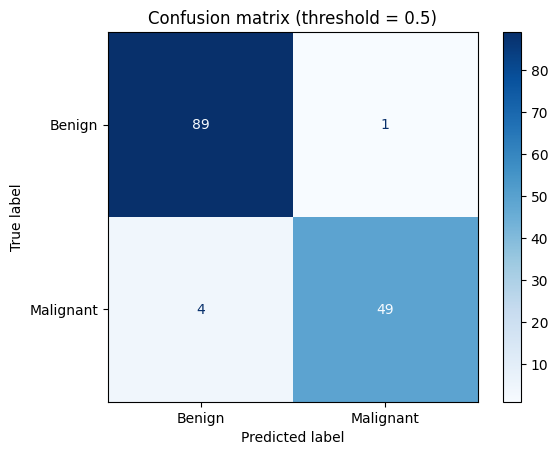

In [4]:
#### Exercise 1 ####
# Change this threshold and run the next cell again.
# Suggested values: 0.3, 0.5, 0.7

threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

##################
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred, pos_label=1)   # malignant
specificity = recall_score(y_test, y_pred, pos_label=0)   # benign
precision = precision_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_prob)

print(f"Threshold:   {threshold}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"ROC AUC:     {auc:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Benign", "Malignant"],
    cmap="Blues"
)
plt.title(f"Confusion matrix (threshold = {threshold})")
plt.show()

# OBservations:
# - Lower threshold -> usually higher sensitivity
# - Higher threshold -> usually higher specificity and fewer false positives
# - In screening, missing malignant cases is often a major concern



## 4) Compare several thresholds at once

Now we compare multiple thresholds in one table.

### Your task
Change the list below. For example, try:
- `[0.2, 0.5, 0.8]`
- `[0.3, 0.5, 0.7]`

Then look at the trade-off:

- lower threshold -> catch more malignant cases
- higher threshold -> fewer false alarms


In [5]:

thresholds = [0.3, 0.5, 0.7]

rows = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)

    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, pred_t),
        "sensitivity": recall_score(y_test, pred_t, pos_label=1),
        "specificity": recall_score(y_test, pred_t, pos_label=0),
        "precision": precision_score(y_test, pred_t, pos_label=1),
    })

results_df = pd.DataFrame(rows)
results_df.round(3)

# Example solution ideas:
# - threshold 0.3 often gives higher sensitivity
# - threshold 0.7 often gives higher specificity
# - there is usually no single "best" threshold for every clinical situation


,threshold,accuracy,sensitivity,specificity,precision
0,0.3,0.979,0.962,0.989,0.981
1,0.5,0.965,0.925,0.989,0.980
2,0.7,0.965,0.906,1.000,1.000


## 5) ROC curve = all thresholds shown as points

In Exercise 4, we compared several thresholds in a table. Now we use the same idea to build the **ROC curve**.

Each threshold gives:
- a **TPR** (true positive rate) = sensitivity
- a **FPR** (false positive rate) = 1 - specificity

So each threshold becomes **one point** in the ROC plot.

### Intuition
- A **high threshold** is strict: fewer patients are predicted malignant  
  → fewer false alarms, but also more missed malignant cases
- A **low threshold** is less strict: more patients are predicted malignant  
  → we catch more malignant cases, but we also create more false alarms

The ROC curve is simply the collection of these points across many thresholds.


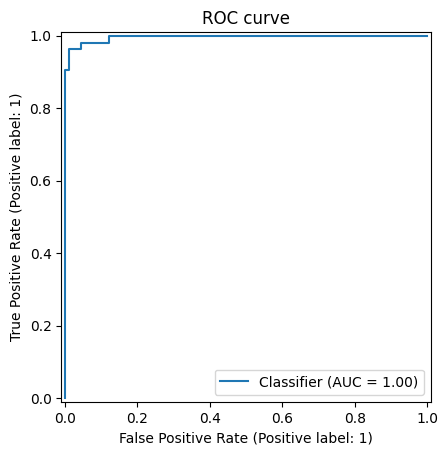

In [6]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC curve")
plt.show()

### What do we see?

Each point in the ROC plot corresponds to **one threshold**.

When we lower the threshold:
- **TPR / sensitivity** usually goes up
- but **FPR** usually also goes up

So the ROC curve shows the trade-off between:
- catching more malignant cases
- and creating more false alarms


## Recap

1. Which threshold would you choose for a **screening tool**?
2. Why is **accuracy alone** not enough in medicine?
3. What happens to **sensitivity** when you lower the threshold?

Answers:
1. Many people would choose a lower threshold for screening, because it catches more malignant cases.
2. A model can have high accuracy but still miss important malignant cases.
3. Lowering the threshold usually increases sensitivity, but may also increase false positives.
